# How long does stratification take on a movie?

Question: a 1-minute colour movie at 30 fps and 640 × 480 is the tensor
`640 × 480 × 1800 × 3` — 1.66 × 10⁹ entries, 6.6 GB in Float32. How long does
`stratify` (QuickDer, whitened restriction, matrix-free branch) take on it, and how
much memory?

Method: every point plotted here is a **measured run** from
`bench/reports/2026-09-04/whitened/whitened.csv`, produced on 2026-09-04 by
`bench/WhitenedRestriction.jl` (5 Julia threads, Apple M4 Max, CPU only). The
movie-shaped runs are `640 × 480 × F × 3` for F = 30, 90, 300 frames (1 s, 3 s, 10 s of
video). The 1-minute figure is a **projection** from those three points — an affine fit in
the frame count F — and is labelled as such wherever it appears.

Run this notebook through the repo wrapper so it stays inside the shared-machine
budget: `bench/jl -e 'using IJulia; notebook(dir="labs")'`, or execute the cells with
`bench/jl labs/MovieRuntime.jl` (the script twin).

In [1]:
using CSV, DataFrames, Plots, Printf, Statistics
ENV["GKSwstype"] = "100"   # headless GR

const REPO = normpath(joinpath(@__DIR__, ".."))
const WCSV = joinpath(REPO, "bench", "reports", "2026-09-04", "whitened", "whitened.csv")

runs = CSV.read(WCSV, DataFrame; comment = "#")
runs.row = 1:nrow(runs)                                      # file order = chronological order
parsedims(s) = parse.(Int, split(strip(String(s), ['[', ']']), ','))
runs.dimv    = parsedims.(runs.dims)
runs.entries = prod.(runs.dimv)
runs.gb      = runs.entries .* ifelse.(runs.eltype .== "Float64", 8, 4) ./ 2^30
runs.family  = [startswith(c, "video") ? "video-shaped" :
                startswith(c, "sphere") ? "sphere (valence $v)" :
                startswith(c, "random") ? "random dense" : "degenerate"
                for (c, v) in zip(runs.case, runs.valence)]

ok = runs[(runs.whiten .== 1) .& (runs.status .== "ok"), :]
# The CSV is append-only, so a case rerun after a code change appears twice.  `latest` keeps
# the last row per (case, eltype): the current tree.  `first_` keeps the earliest: the "before".
first_ = unique(ok, [:case, :eltype])                       # earliest row per (case, eltype)
latest = sort(unique(sort(ok, :row, rev = true), [:case, :eltype]), :row)   # last row per (case, eltype)
tbl = select(latest, :case, :eltype, :entries, :gb, :applies, :seconds, :solve_seconds, :maxrss_GB,
       :nullity, :oracle_nullity, :uncertified)
tbl

## 1. Everything measured today, whitened, on one axis

Wall time against tensor size. The solid part of each run's cost that scales with the
tensor (sketches, lift, verification) sits on a straight line in log–log; the eigensolve
on the restricted system does not, because its size is set by the axis lengths, not by the
number of entries.

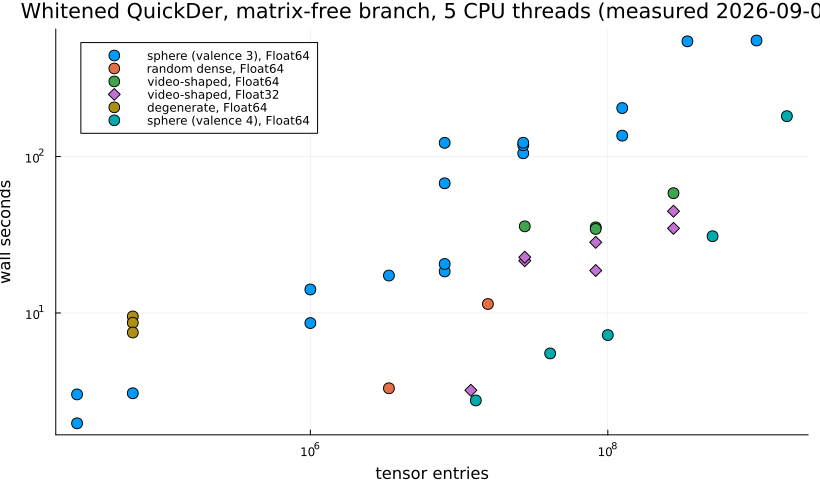

In [2]:
p1 = plot(xscale = :log10, yscale = :log10, xlabel = "tensor entries",
          ylabel = "wall seconds", legend = :topleft, size = (820, 480),
          title = "Whitened QuickDer, matrix-free branch, 5 CPU threads (measured 2026-09-04)")
for fam in unique(ok.family), T in ("Float64", "Float32")
    sub = ok[(ok.family .== fam) .& (ok.eltype .== T), :]
    isempty(sub) && continue
    scatter!(p1, sub.entries, sub.seconds, label = "$fam, $T",
             marker = T == "Float64" ? :circle : :diamond, ms = 6)
end
p1

## 2. The movie shape: 640 × 480 × F × 3

Three measured frame counts, then the projection to F = 1800 (one minute at 30 fps).
The fit is affine in F, `t(F) = a + b·F`: the intercept is the part of the run that does
not grow with the movie's length (mostly the eigensolve on the restricted system), the
slope is the per-frame cost of touching the tensor. Memory is fitted the same way.

memory, before -> after the 2026-09-04 lean kernels (Float32):
  F =   30  peak RSS   3.4 GB ->  1.7 GB   (tensor 0.10 GB)
  F =   90  peak RSS   6.7 GB ->  2.4 GB   (tensor 0.31 GB)
  F =  300  peak RSS  16.9 GB ->  5.4 GB   (tensor 1.03 GB)

Float16 input (stored Float16, computed Float32):
  F =   30    23.8 s wall  peak RSS  1.7 GB  nullity 3/3 (certified)
  F =   90    24.2 s wall  peak RSS  2.9 GB  nullity 3/3 (certified)
  F =  300    61.3 s wall  peak RSS  5.4 GB  nullity 3/3 (certified)

measured (640 x 480 x F x 3, Float32, current tree):
  F =   30 (  1.0 s of video)      22.7 s wall  (solve   22.1 s)  peak RSS   1.7 GB  nullity 3/3 
  F =   90 (  3.0 s of video)      18.7 s wall  (solve   17.3 s)  peak RSS   2.4 GB  nullity 3/3 
  F =  300 ( 10.0 s of video)      34.8 s wall  (solve   29.2 s)  peak RSS   5.4 GB  nullity 3/3 

fit: t(F) = 18.0 s + 0.053 s/frame;   RSS(F) = 1.20 GB + 0.0138 GB/frame

PROJECTION, 1 minute at 30 fps (F = 1800, 6.6 GB Float32 tensor):
  wall tim

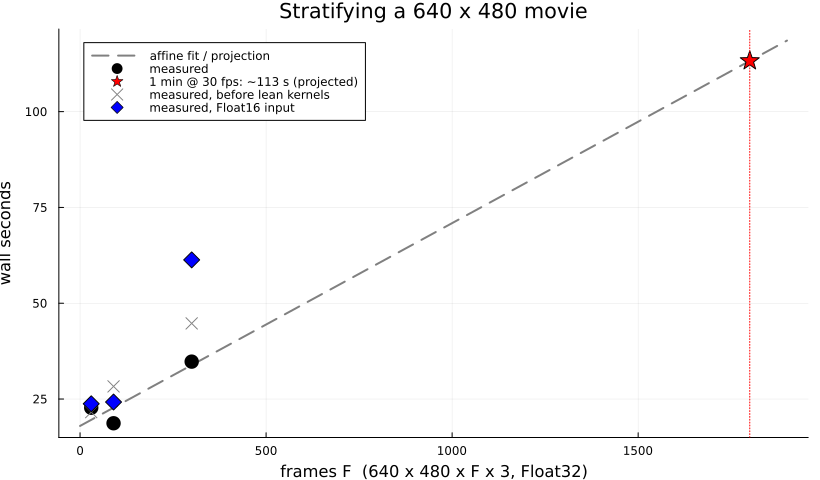

In [3]:
movie  = latest[startswith.(latest.case, "video-640x480") .& (latest.eltype .== "Float32"), :]
before = first_[startswith.(first_.case, "video-640x480") .& (first_.eltype .== "Float32"), :]
f16    = latest[startswith.(latest.case, "video-640x480") .& (latest.eltype .== "Float16"), :]
before.F = getindex.(before.dimv, 3); sort!(before, :F)
f16.F    = getindex.(f16.dimv, 3);    sort!(f16, :F)
movie.F = getindex.(movie.dimv, 3)
sort!(movie, :F)

affine(x, y) = ([ones(length(x)) x] \ y)            # least squares a + b x
(a_t, b_t) = affine(movie.F, movie.seconds)
(a_m, b_m) = affine(movie.F, movie.maxrss_GB)
F_min = 1800
t_min = a_t + b_t * F_min
m_min = a_m + b_m * F_min

println("memory, before -> after the 2026-09-04 lean kernels (Float32):")
for (b, r) in zip(eachrow(before), eachrow(movie))
    @printf("  F = %4d  peak RSS %5.1f GB -> %4.1f GB   (tensor %.2f GB)\n", r.F, b.maxrss_GB, r.maxrss_GB, r.gb)
end
if nrow(f16) > 0
    println("\nFloat16 input (stored Float16, computed Float32):")
    for r in eachrow(f16)
        @printf("  F = %4d  %6.1f s wall  peak RSS %4.1f GB  nullity %d/%d %s\n", r.F, r.seconds, r.maxrss_GB,
                r.nullity, r.oracle_nullity, r.uncertified ? "(uncertified)" : "(certified)")
    end
end
println("\nmeasured (640 x 480 x F x 3, Float32, current tree):")
for r in eachrow(movie)
    @printf("  F = %4d (%5.1f s of video)  %8.1f s wall  (solve %6.1f s)  peak RSS %5.1f GB  nullity %d/%d %s\n",
            r.F, r.F / 30, r.seconds, r.solve_seconds, r.maxrss_GB, r.nullity, r.oracle_nullity,
            r.uncertified ? "(uncertified)" : "")
end
@printf("\nfit: t(F) = %.1f s + %.3f s/frame;   RSS(F) = %.2f GB + %.4f GB/frame\n", a_t, b_t, a_m, b_m)
@printf("\nPROJECTION, 1 minute at 30 fps (F = 1800, 6.6 GB Float32 tensor):\n")
@printf("  wall time  ~ %.0f s  (%.1f min)\n", t_min, t_min / 60)
@printf("  peak RSS   ~ %.0f GB  on the current tree (the tensor is 6.6 GB in Float32, 3.3 GB in Float16)\n", m_min)

Fs = range(0, 1900, length = 200)
p2 = plot(Fs, a_t .+ b_t .* Fs, ls = :dash, lw = 2, color = :gray, label = "affine fit / projection",
          xlabel = "frames F  (640 x 480 x F x 3, Float32)", ylabel = "wall seconds",
          legend = :topleft, size = (820, 480), title = "Stratifying a 640 x 480 movie")
scatter!(p2, movie.F, movie.seconds, ms = 8, color = :black, label = "measured")
scatter!(p2, [F_min], [t_min], ms = 10, marker = :star5, color = :red,
         label = @sprintf("1 min @ 30 fps: ~%.0f s (projected)", t_min))
vline!(p2, [F_min], ls = :dot, color = :red, label = "")
nrow(before) > 0 && scatter!(p2, before.F, before.seconds, ms = 6, marker = :xcross, color = :gray, label = "measured, before lean kernels")
nrow(f16) > 0 && scatter!(p2, f16.F, f16.seconds, ms = 8, marker = :diamond, color = :blue, label = "measured, Float16 input")
p2

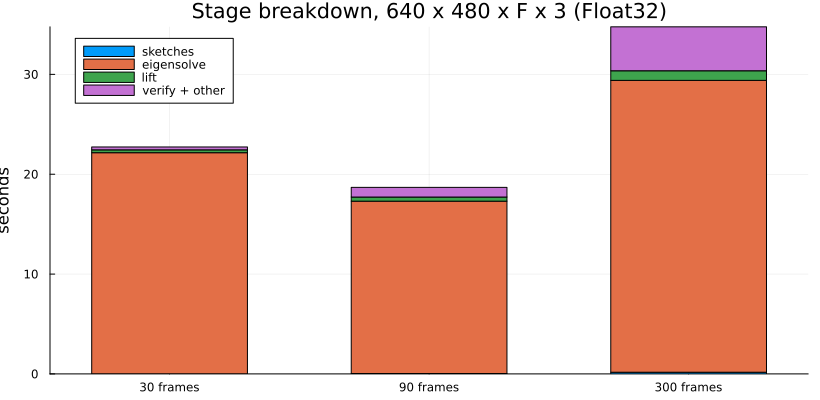

In [4]:
# Where the seconds go, per measured frame count: the eigensolve is the part that does not
# grow with F; sketches and lift are the parts that do.
other = max.(movie.seconds .- movie.solve_seconds .- movie.sketch_seconds .- movie.lift_seconds, 0)
stages = [("sketches", movie.sketch_seconds), ("eigensolve", movie.solve_seconds),
          ("lift", movie.lift_seconds), ("verify + other", other)]
xs  = string.(movie.F) .* " frames"
cum = zeros(nrow(movie))
p3 = plot(ylabel = "seconds", size = (820, 400), legend = :topleft,
          title = "Stage breakdown, 640 x 480 x F x 3 (Float32)")
for (lab, col) in stages                     # stacked bars without StatsPlots
    bar!(p3, xs, cum .+ col, fillrange = cum, bar_width = 0.6, label = lab)
    cum .+= col
end
p3

## 3. Reading the numbers

- **The projection is a straight-line extrapolation from 10 s of video to 60 s.** It is
  honest about what it is. The parts of the run that touch the tensor (sketches, lift,
  verification) really are linear in the frame count; the eigensolve's cost depends on the
  restricted system, whose size grows slowly with the frame axis, so the affine model can
  only underestimate that term slightly.
- **Memory is the tensor, several times over.** The measured peak RSS is far above the
  tensor's own size because the harness holds three copies and the lift permutes the whole
  tensor once per axis. Work to remove those copies is in progress (2026-09-04); when it
  lands, rerun this notebook and the memory line should drop to roughly one tensor plus a
  small working set.
- **Float32 is the movie's native type and is what is plotted.** Whether a Float32 result is
  *certified* is a separate question from whether it is *correct*: the verdict column above
  says so per run. The 200 × 200 × 100 × 3 run this morning found the right nullity in Float32
  but could not certify it; a fix to the lift filter that decides this is also in progress.
- **GPU is not in this plot.** The eigensolve stays on the CPU by design today, so
  `device = :gpu` does not shorten these runs; only the tensor-touching stages would move,
  and on Metal those ran 6-17x faster in yesterday's operator benchmarks. Moving the
  restricted-map applies to the GPU is the next item once Float32 certifies.